# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [ ]:
# untuk plot Q-Q
import scipy.stats as stats

In [ ]:
df_california = pd.read_csv('california_dataset.csv')

In [ ]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

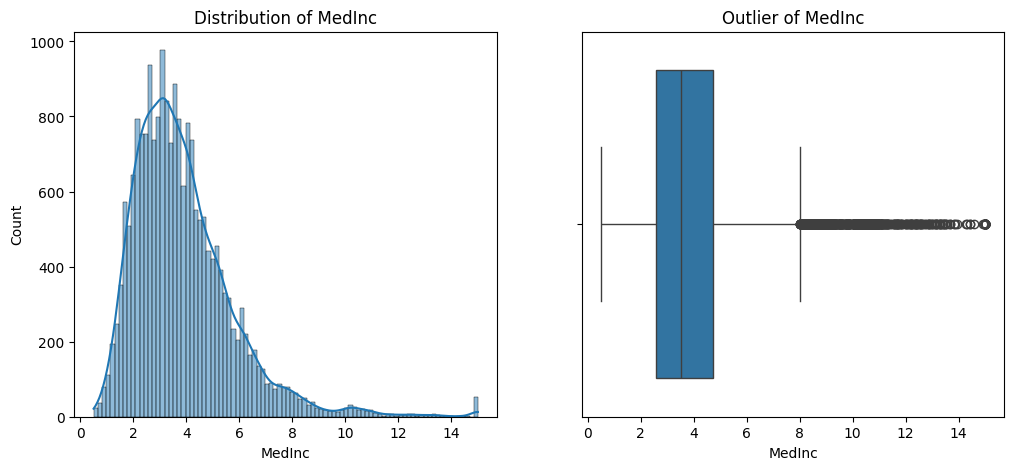

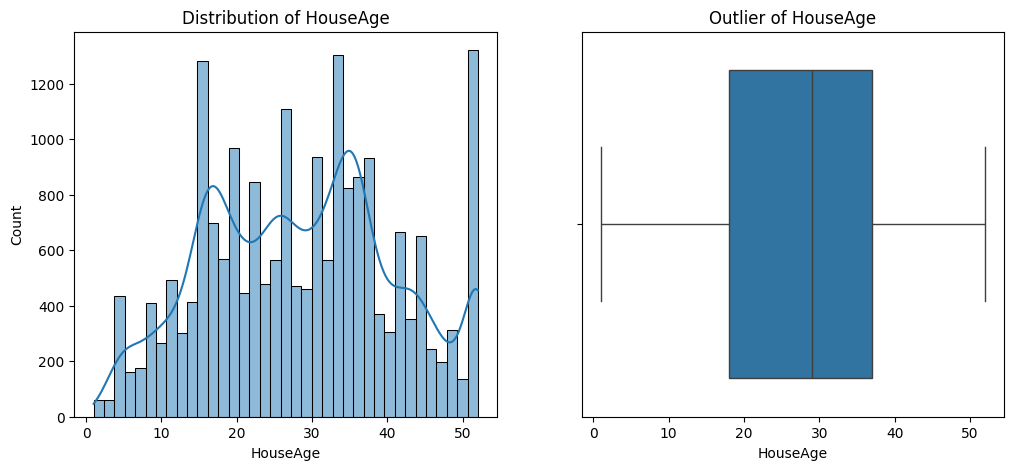

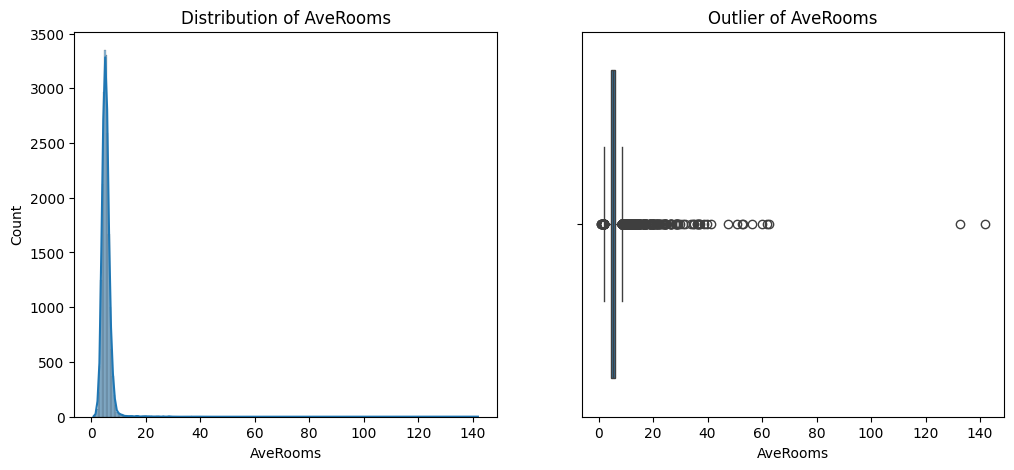

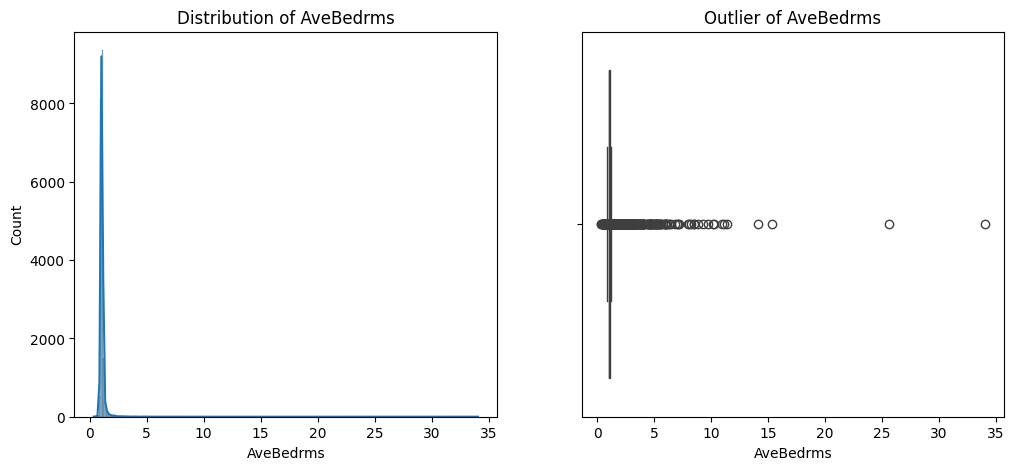

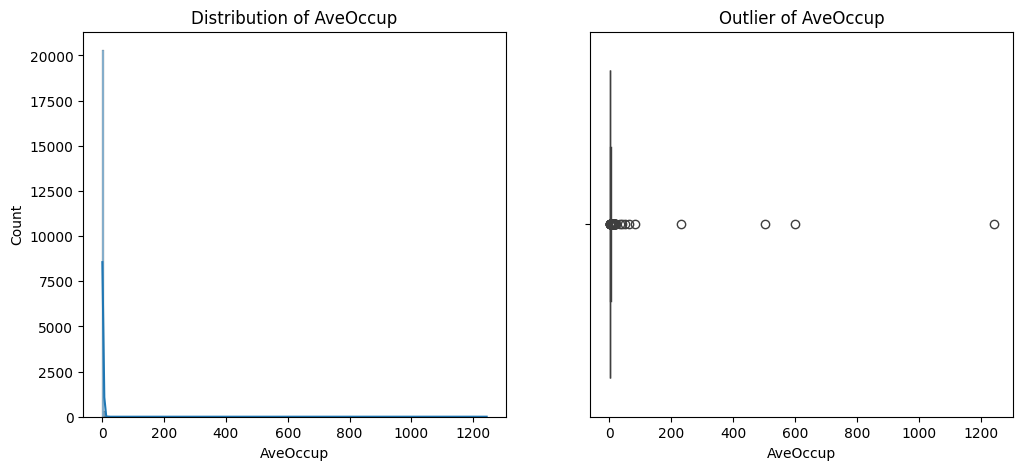

In [ ]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
#Tulis jawaban
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in cols:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df_california[col])
    plt.title(f'Outlier of {col}')
    
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

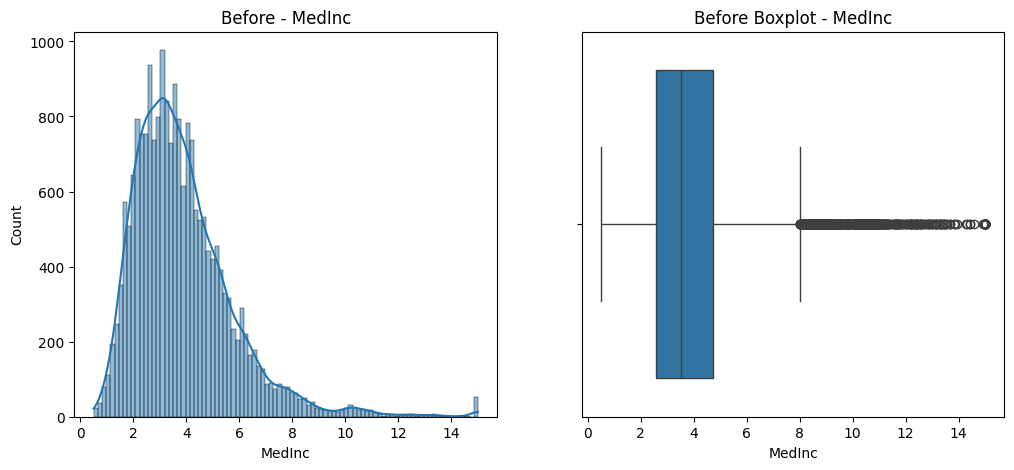

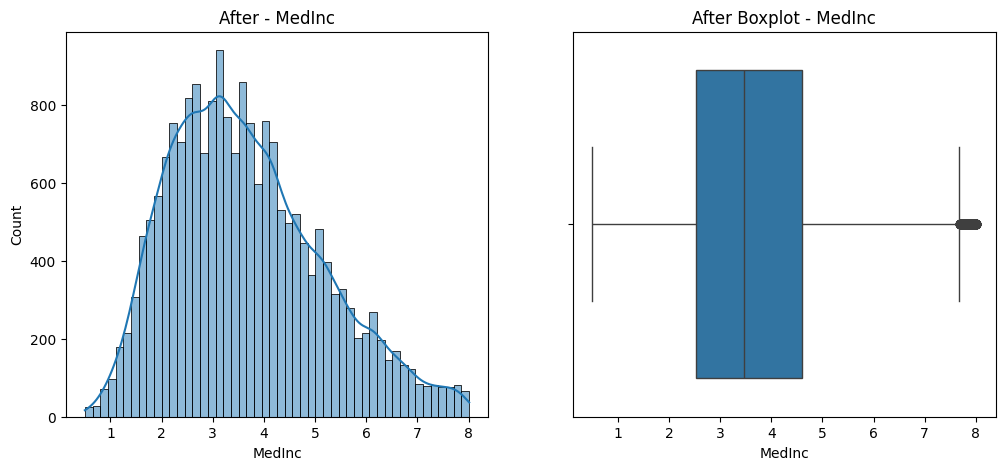

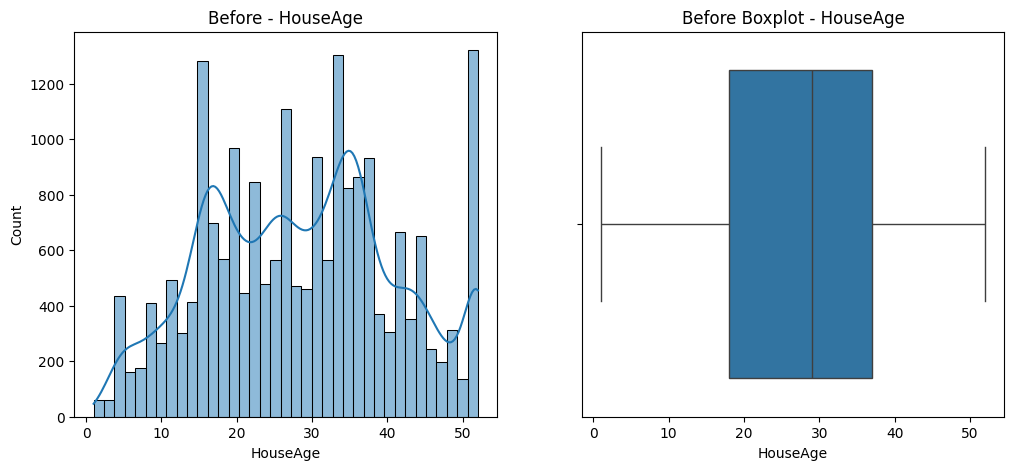

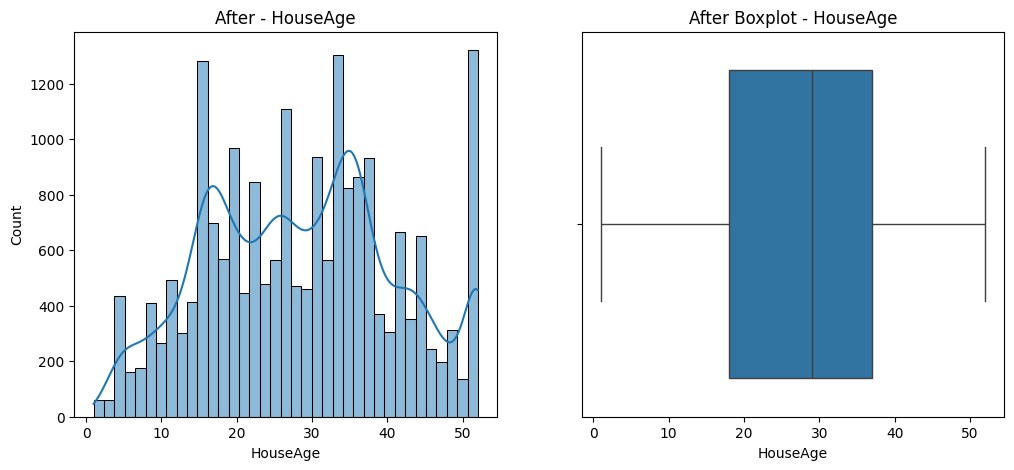

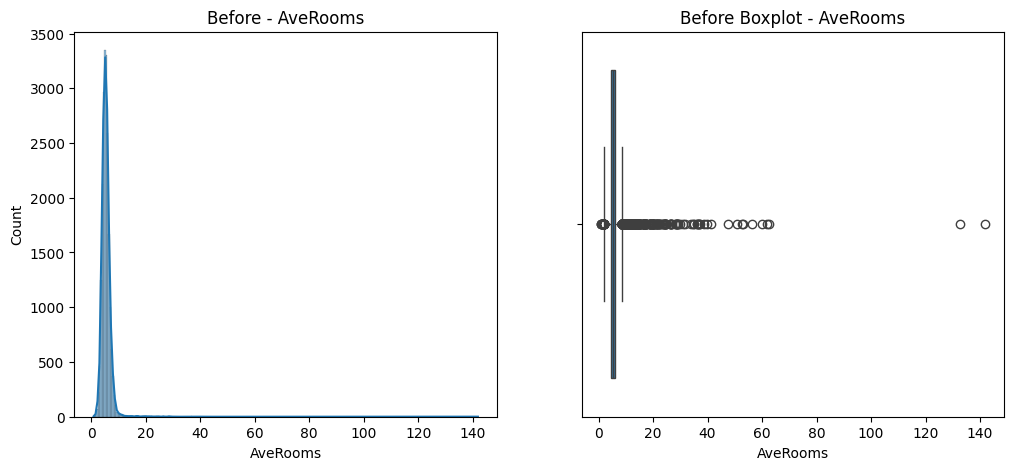

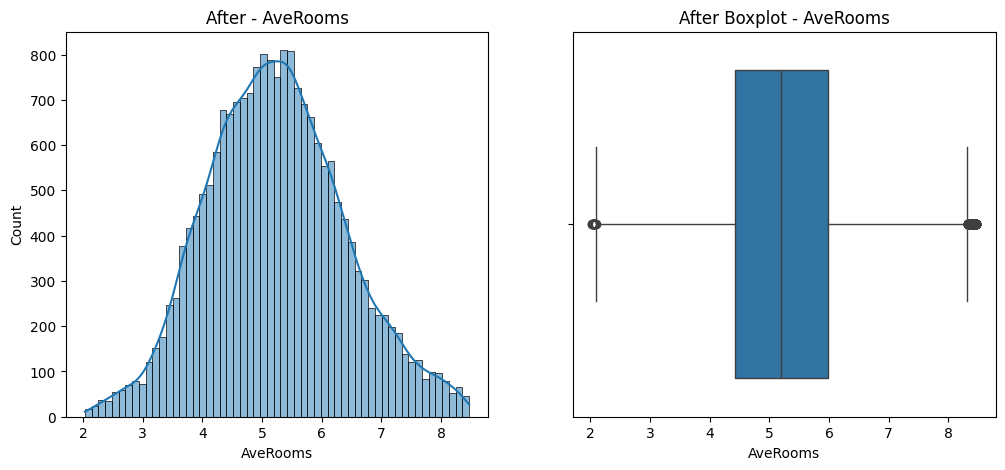

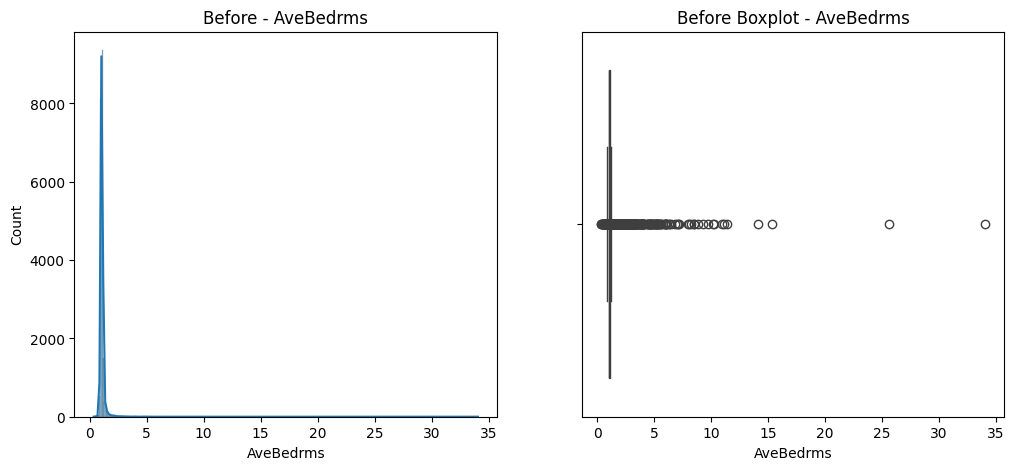

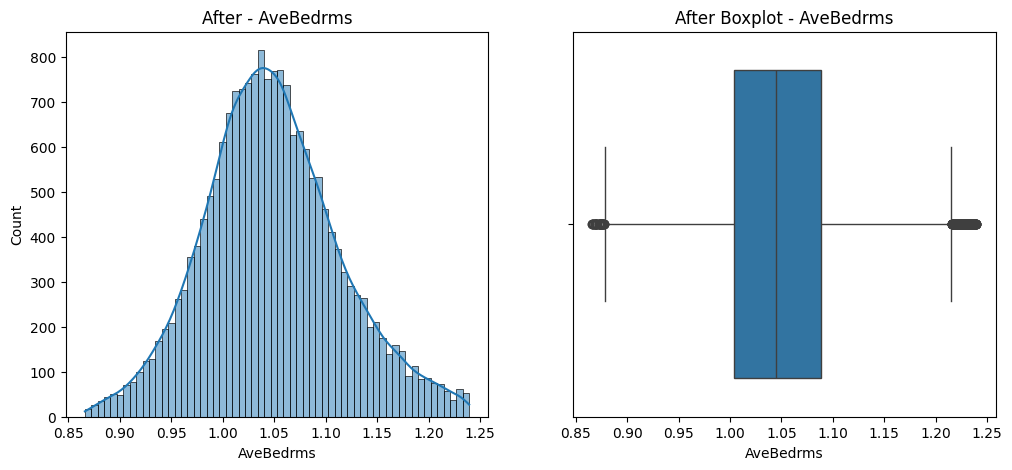

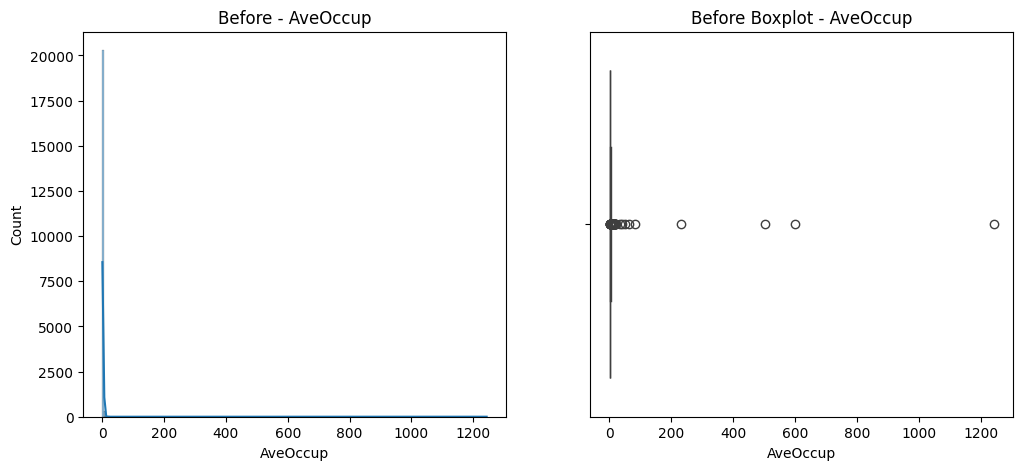

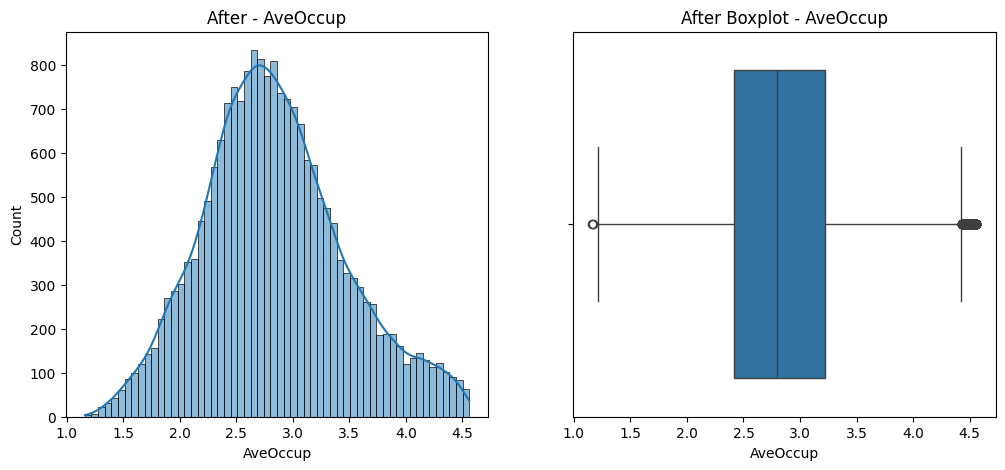

In [ ]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
#Tulis jawaban
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in cols:
    # simpan data asli
    df_temp = df_california.copy()

    # =====================
    # SEBELUM
    # =====================
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.histplot(df_temp[col], kde=True)
    plt.title(f'Before - {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df_temp[col])
    plt.title(f'Before Boxplot - {col}')

    plt.show()

    # =====================
    # IQR
    # =====================
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_temp = df_temp[
        (df_temp[col] >= lower) & (df_temp[col] <= upper)
    ]

    # =====================
    # SESUDAH
    # =====================
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.histplot(df_temp[col], kde=True)
    plt.title(f'After - {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df_temp[col])
    plt.title(f'After Boxplot - {col}')

    plt.show()

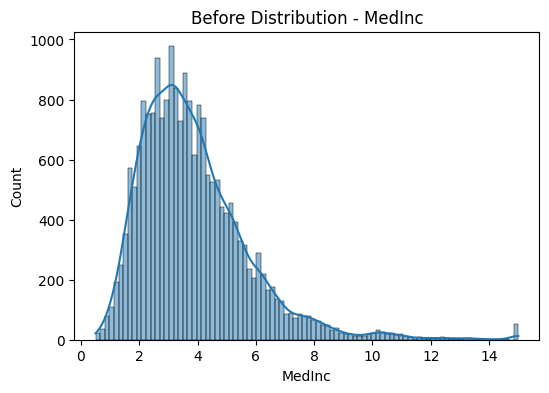

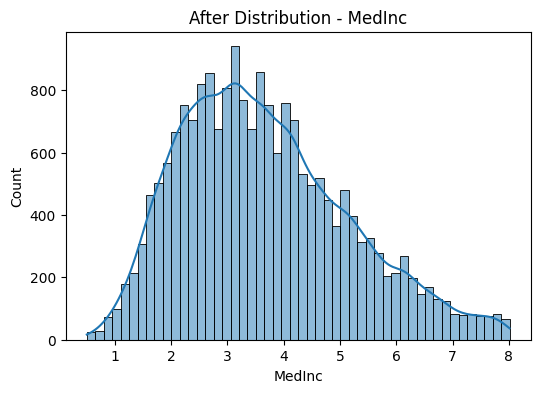

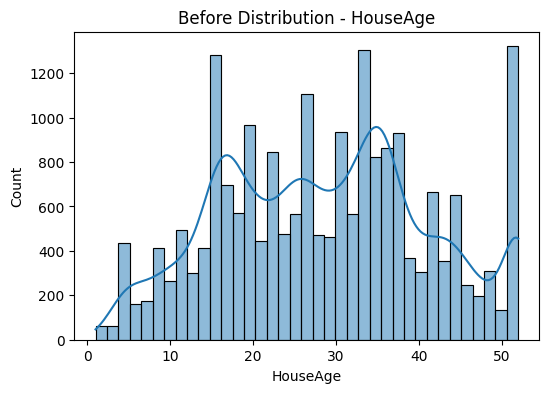

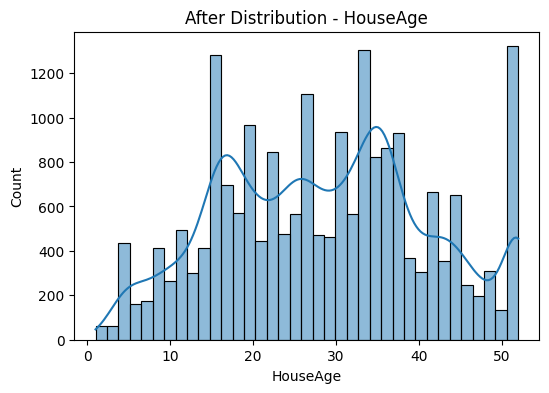

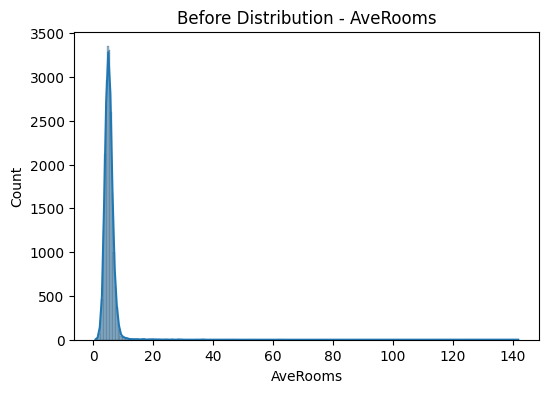

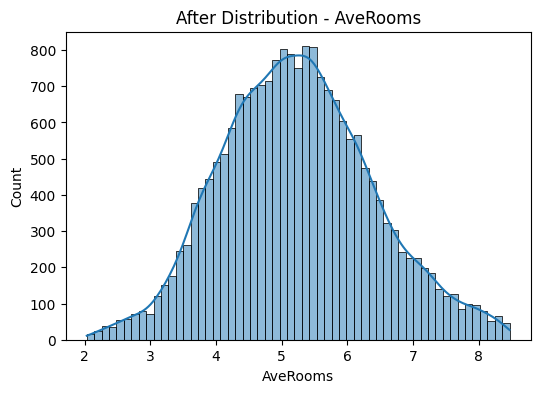

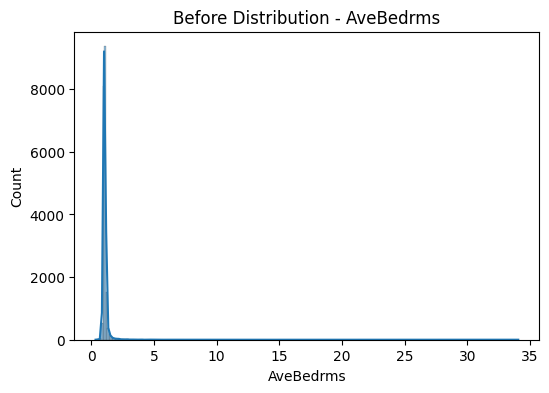

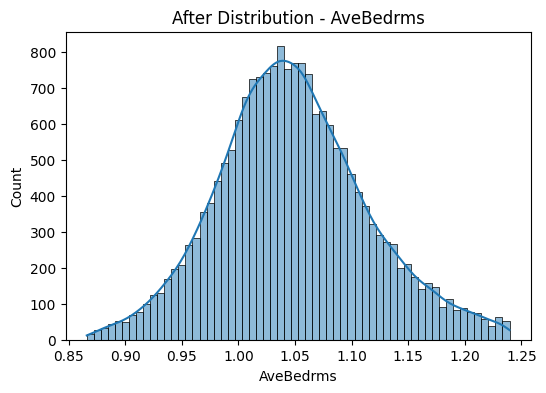

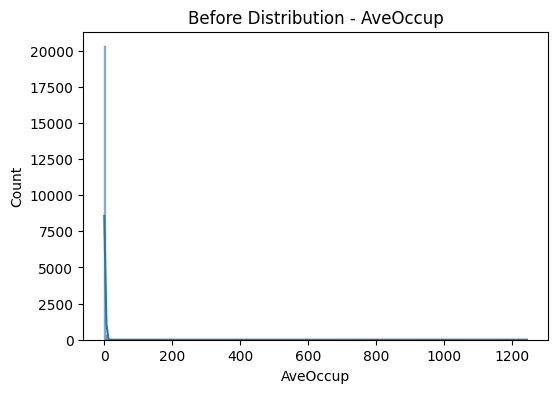

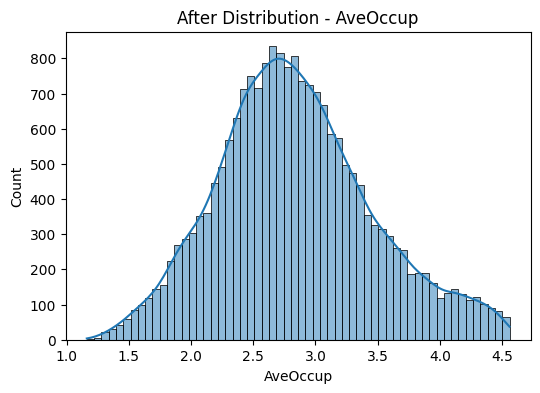

In [ ]:
# Melakukan loop untuk mengecek distribusi tiap kolom
#Tulis jawaban
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in cols:
    # gunakan copy supaya tidak merusak data asli
    df_temp = df_california.copy()

    # =====================
    # SEBELUM (Distribusi)
    # =====================
    plt.figure(figsize=(6,4))
    sns.histplot(df_temp[col], kde=True)
    plt.title(f'Before Distribution - {col}')
    plt.show()

    # =====================
    # IQR PROCESS
    # =====================
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_temp = df_temp[
        (df_temp[col] >= lower) & (df_temp[col] <= upper)
    ]

    # =====================
    # SESUDAH (Distribusi)
    # =====================
    plt.figure(figsize=(6,4))
    sns.histplot(df_temp[col], kde=True)
    plt.title(f'After Distribution - {col}')
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [ ]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [ ]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#Tulis jawaban

# cek missing value
missing = df_company['Headquarters'].isnull().sum()
total = len(df_company)

print("Missing:", missing)
print("Persentase:", (missing/total)*100, "%")

# karena kategorikal → isi dengan modus
mode_val = df_company['Headquarters'].mode()[0]
df_company['Headquarters'].fillna(mode_val, inplace=True)

# validasi
print("Sisa missing:", df_company['Headquarters'].isnull().sum())


Missing: 0
Persentase: 0.0 %
Sisa missing: 0


C:\Users\User\AppData\Local\Temp\ipykernel_19504\3627447552.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_company['Headquarters'].fillna(mode_val, inplace=True)


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
#Tulis jawaban missing value handling kolom Headquarters disini
import pandas as pd

df_company = pd.read_csv('company.csv')

# 1. Cek jumlah & persentase missing value
missing = df_company['Headquarters'].isnull().sum()
total = len(df_company)
percentage = (missing / total) * 100

print("Jumlah missing:", missing)
print("Persentase missing:", percentage, "%")

# Cek jenis missing value
print("Tipe data:", df_company['Headquarters'].dtype)
print("Isi unik:", df_company['Headquarters'].unique())


# 2. Keputusan drop atau tidak
if percentage > 20:
    print("Kolom di-drop karena missing > 20%")
    df_company.drop('Headquarters', axis=1, inplace=True)
else:
    print("Kolom tidak di-drop karena missing <= 20%")


# 3. Handling missing value
# Karena kolom Headquarters bertipe kategorik → gunakan modus
if 'Headquarters' in df_company.columns:
    mode_val = df_company['Headquarters'].mode()[0]
    df_company['Headquarters'].fillna(mode_val, inplace=True)

    # Validasi
    print("Sisa missing setelah handling:", df_company['Headquarters'].isnull().sum())

Jumlah missing: 0
Persentase missing: 0.0 %
Tipe data: str
Isi unik: <StringArray>
[          'New York, NY',            'Herndon, VA',             'Boston, MA',
 'Bad Ragaz, Switzerland',      'Santa Barbara, CA',     'Basel, Switzerland',
            'Bedford, MA',      'Mountain View, CA',            'Chicago, IL',
            'Mc Lean, VA',
 ...
            'Langley, VA',              'Plano, TX',        'Albertville, AL',
             'Orange, CA',          'Littleton, CO',       'Oakville, Canada',
          'San Bruno, CA',       'West Chester, PA',              'Utica, MI',
           'Fort Lee, NJ']
Length: 229, dtype: str
Kolom tidak di-drop karena missing <= 20%
Sisa missing setelah handling: 0


C:\Users\User\AppData\Local\Temp\ipykernel_19504\1262805315.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_company['Headquarters'].fillna(mode_val, inplace=True)


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [10]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
#Tulis jawaban
import pandas as pd

# pastikan file ada di folder yang sama ATAU pakai path lengkap
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

# 1. One Hot Encoding
df_churn = pd.get_dummies(df_churn, columns=['gender'], drop_first=True)

# 2. Label Encoding
for col in ['Partner', 'Dependents']:
    df_churn[col] = df_churn[col].map({'Yes': 1, 'No': 0})

# 3. Mean Encoding
df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})
mean_contract = df_churn.groupby('Contract')['Churn'].mean()
df_churn['Contract_mean'] = df_churn['Contract'].map(mean_contract)

print(df_churn.head())

   customerID  SeniorCitizen  Partner  Dependents  tenure PhoneService  \
0  7590-VHVEG              0        1           0       1           No   
1  5575-GNVDE              0        0           0      34          Yes   
2  3668-QPYBK              0        0           0       2          Yes   
3  7795-CFOCW              0        0           0      45           No   
4  9237-HQITU              0        0           0       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No              No  Month-to-month           

In [11]:
#Tulis jawaban
import pandas as pd
import os

# ======================
# CEK FILE (WAJIB)
# ======================
print("Current folder:", os.getcwd())
print("Isi folder:", os.listdir())

# ======================
# LOAD DATA (AMAN)
# ======================
# GANTI PATH kalau file tidak muncul di atas
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

print("Data berhasil dibaca")
print(df_churn.head())


# ======================
# CEK KOLOM (PENTING)
# ======================
print("Kolom:", df_churn.columns)


# ======================
# 1. ONE HOT ENCODING
# ======================
if 'gender' in df_churn.columns:
    df_churn = pd.get_dummies(df_churn, columns=['gender'], drop_first=True)


# ======================
# 2. LABEL ENCODING
# ======================
for col in ['Partner', 'Dependents']:
    if col in df_churn.columns:
        df_churn[col] = df_churn[col].map({'Yes': 1, 'No': 0})


# ======================
# 3. MEAN ENCODING
# ======================
if 'Churn' in df_churn.columns:
    df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})

if 'Contract' in df_churn.columns:
    mean_contract = df_churn.groupby('Contract')['Churn'].mean()
    df_churn['Contract_mean'] = df_churn['Contract'].map(mean_contract)


# ======================
# HASIL
# ======================
print("\nHASIL AKHIR:")
print(df_churn.head())

Current folder: c:\Tugas Kuliah\Semester 5\Machine Learning
Isi folder: ['.git', 'Assignment_Week 3.ipynb', 'california_dataset.csv', 'company.csv', 'Hands On_Week_3_Feature_Engineering.ipynb', 'Hands_On_Function_in_Python.ipynb', 'Hands_On_Main_Principles_of_OOP.ipynb', 'Hands_On_OOP_Paradigm_Concepts.ipynb', 'TelcoCustomerChurn.csv', 'TelcoCustomerChurn.xlsx', 'titanic.xlsx', 'Week2_Tipe_Data.ipynb']
Data berhasil dibaca
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone serv

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [12]:
#Tulis jawaban
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 4. Load dataset
df = pd.read_csv('TelcoCustomerChurn.csv')

# 1. Pilih kolom
cols = [
    'StreamingMovies', 'StreamingTV', 'TechSupport',
    'DeviceProtection', 'OnlineBackup', 'OnlineSecurity',
    'MultipleLines'
]

df_selected = df[cols].copy()

# 2. Ganti nilai & validasi
for col in cols:
    df_selected[col] = df_selected[col].replace('No internet service', 'No')

# Validasi sebelum encoding
for col in cols:
    print(f"Value counts BEFORE - {col}")
    print(df_selected[col].value_counts())
    print('-'*40)

# 3. Label Encoding
le = LabelEncoder()

for col in cols:
    df_selected[col] = le.fit_transform(df_selected[col])

# Validasi setelah encoding
for col in cols:
    print(f"Value counts AFTER - {col}")
    print(df_selected[col].value_counts())
    print('-'*40)

Value counts BEFORE - StreamingMovies
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
----------------------------------------
Value counts BEFORE - StreamingTV
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
----------------------------------------
Value counts BEFORE - TechSupport
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
----------------------------------------
Value counts BEFORE - DeviceProtection
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
----------------------------------------
Value counts BEFORE - OnlineBackup
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
----------------------------------------
Value counts BEFORE - OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
----------------------------------------
Value counts BEFORE - MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
-

## Selesai :)